In [3]:
#model impementation
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
df = pd.read_csv("dataset/advertising_cleaned.csv")

     

In [6]:

platform = ['TV','Radio','Newspaper' ]

target = ['Sales']     

In [7]:
X=df[platform]
Y=df[target]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [11]:
#LINEAR REGRESSION MODEL

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Weights (Coefficients):", dict(zip(X.columns, model.coef_)))

Intercept: [2.97906734]
Weights (Coefficients): {'TV': array([0.04472952, 0.18919505, 0.00276111])}


In [13]:
# 1. R-squared (R2) Score
r2 = r2_score(Y_test, y_pred)
print(f"R² Score: {r2:.4f}")

# 2. Mean Absolute Error (MAE)
mae = mean_absolute_error(Y_test, y_pred)
print(f"MAE: {mae:.4f}")

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
print(f"RMSE: {rmse:.4f}")
df['TV_Radio_interaction'] = df['TV'] * df['Radio']

R² Score: 0.8994
MAE: 1.4608
RMSE: 1.7816


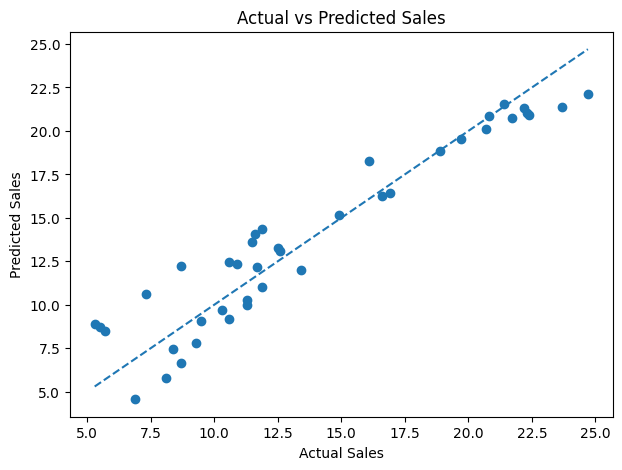

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(Y_test, y_pred)

plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

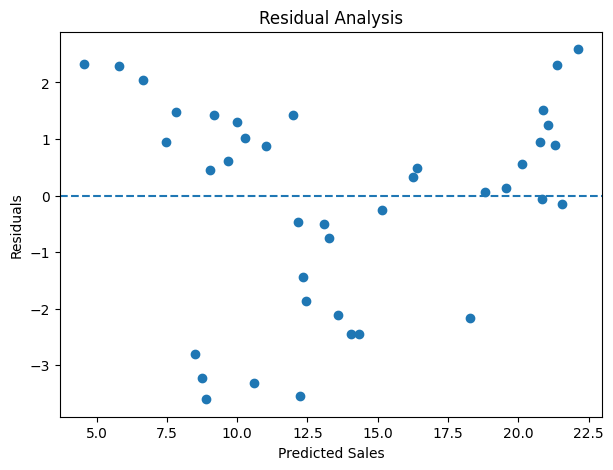

In [14]:
residuals = Y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Initialize and fit the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# Using .values.ravel() to pass target as a 1D array
rf_model.fit(X_train, Y_train.values.ravel())

# 2. Make predictions on test set
rf_pred = rf_model.predict(X_test)

# 3. Calculate evaluation metrics
rf_r2 = r2_score(Y_test, rf_pred)
rf_mae = mean_absolute_error(Y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))

# 4. Compare side-by-side with Linear Regression
comparison_df = pd.DataFrame({
    "Metric": ["R² Score", "MAE", "RMSE"],
    "Linear Regression": [r2_score(Y_test, y_pred), mean_absolute_error(Y_test, y_pred), np.sqrt(mean_squared_error(Y_test, y_pred))],
    "Random Forest": [rf_r2, rf_mae, rf_rmse]
})

print(comparison_df.to_string(index=False))

  Metric  Linear Regression  Random Forest
R² Score           0.899438       0.981284
     MAE           1.460757       0.620100
    RMSE           1.781600       0.768591


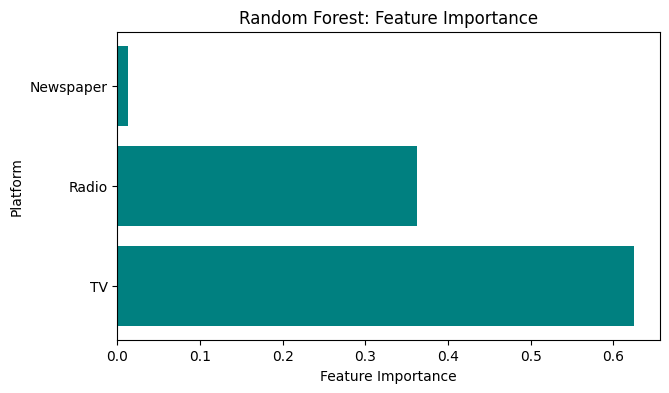

In [23]:

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Plot
plt.figure(figsize=(7, 4))
plt.barh(feature_names, importances, color='teal')
plt.xlabel("Feature Importance")
plt.ylabel("Platform")
plt.title("Random Forest: Feature Importance")
plt.show()

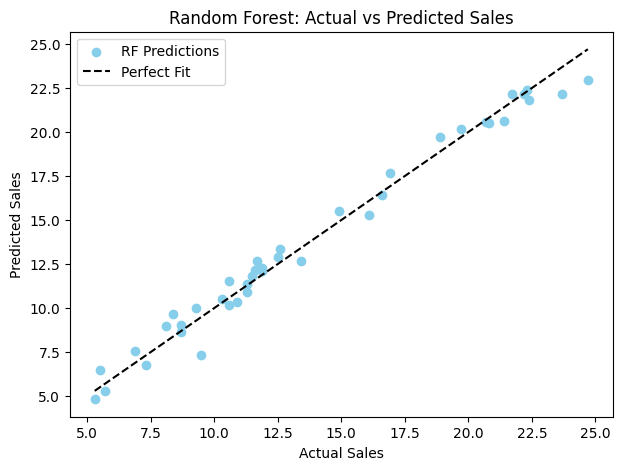

In [22]:
#actual vs predicted sales for random forest model
plt.figure(figsize=(7, 5))
plt.scatter(Y_test, rf_pred, color='skyblue', label='RF Predictions')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'k--', label='Perfect Fit')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted Sales")
plt.legend()
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV, KFold

# 1. Set up 5-fold cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define parameter grid to tune
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Grid search to find best parameters
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train.values.ravel())

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

# 4. Evaluate the tuned model on the unseen test set
best_rf = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test)

print(f"Tuned Test R²: {r2_score(Y_test, tuned_pred):.4f}")
print(f"Tuned Test RMSE: {np.sqrt(mean_squared_error(Y_test, tuned_pred)):.4f}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE: 0.8852355121446722
Tuned Test R²: 0.9815
Tuned Test RMSE: 0.7648


In [27]:
import joblib

# 'best_rf' is your fitted RandomForestRegressor model
joblib.dump(best_rf, 'best_random_forest_advertising.joblib')

print("Model saved to disk!")

Model saved to disk!


In [28]:
import joblib
import pandas as pd

# 1. Save the best model
joblib.dump(best_rf, 'best_random_forest_advertising.joblib')
print("Model successfully saved as 'best_random_forest_advertising.joblib'")

# 2. Load the model back
loaded_model = joblib.load('best_random_forest_advertising.joblib')

# 3. Predict sales on new hypothetical advertising budgets
new_campaigns = pd.DataFrame({
    'TV': [200.0, 50.0, 100.0],
    'Radio': [40.0, 10.0, 25.0],
    'Newspaper': [20.0, 5.0, 10.0]
})

predictions = loaded_model.predict(new_campaigns)
new_campaigns['Predicted_Sales'] = np.round(predictions, 2)
print("\nCampaign Predictions:")
print(new_campaigns)

Model successfully saved as 'best_random_forest_advertising.joblib'

Campaign Predictions:
      TV  Radio  Newspaper  Predicted_Sales
0  200.0   40.0       20.0            20.24
1   50.0   10.0        5.0             9.70
2  100.0   25.0       10.0            11.99


In [29]:
import joblib
import pandas as pd

# Load the saved model file
model = joblib.load('best_random_forest_advertising.joblib')

# Predict instantly for any new budget
sample = pd.DataFrame({'TV': [150.0], 'Radio': [30.0], 'Newspaper': [15.0]})
print("Predicted Sales:", model.predict(sample)[0])

Predicted Sales: 16.64618333333332
